# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Dwi Fajar Novianto
- **Email:** dwifajar.2024@student.uny.ac.id
- **ID Dicoding:** Dwi Fajar Novianto

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata.
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.

- **Pertanyaan 1:** Bagaimana tren jumlah pesanan bulanan (Month-over-Month) sepanjang Januari 2017 hingga Agustus 2018, dan 10 kategori produk apa yang memberikan kontribusi revenue terbesar selama periode tersebut?
- **Pertanyaan 2:** Bagaimana segmentasi pelanggan berdasarkan analisis RFM (Recency, Frequency, Monetary) per awal September 2018, dan segmen pelanggan mana yang paling perlu diprioritaskan untuk kampanye retensi?
- **Pertanyaan 3:** Negara bagian (state) mana di Brazil yang memiliki rata-rata waktu pengiriman (delivery time) paling lama selama periode Januari 2017 - Agustus 2018, dan bagaimana hubungannya dengan rata-rata skor ulasan pelanggan di negara bagian tersebut?

## Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

## Data Wrangling

### Gathering Data

#### Load seluruh dataset E-Commerce Public Dataset

In [4]:
DATA_DIR = "data/"

customers = pd.read_csv(DATA_DIR + "customers_dataset.csv")
orders = pd.read_csv(DATA_DIR + "orders_dataset.csv")
order_items = pd.read_csv(DATA_DIR + "order_items_dataset.csv")
order_payments = pd.read_csv(DATA_DIR + "order_payments_dataset.csv")
order_reviews = pd.read_csv(DATA_DIR + "order_reviews_dataset.csv")
products = pd.read_csv(DATA_DIR + "products_dataset.csv")
sellers = pd.read_csv(DATA_DIR + "sellers_dataset.csv")
geolocation = pd.read_csv(DATA_DIR + "geolocation_dataset.csv")
category_translation = pd.read_csv(DATA_DIR + "product_category_name_translation.csv")

print("customers:", customers.shape)
print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("order_payments:", order_payments.shape)
print("order_reviews:", order_reviews.shape)
print("products:", products.shape)
print("sellers:", sellers.shape)
print("geolocation:", geolocation.shape)
print("category_translation:", category_translation.shape)

customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 7)
order_payments: (103886, 5)
order_reviews: (99224, 7)
products: (32951, 9)
sellers: (3095, 4)
geolocation: (1000163, 5)
category_translation: (71, 2)


In [5]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [7]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


**Insight:**
- Dataset terdiri dari 9 tabel terpisah (customers, orders, order_items, order_payments, order_reviews, products, sellers, geolocation, category_translation) yang saling terhubung melalui `order_id`, `customer_id`, `product_id`, dan `seller_id`.
- Untuk menjawab pertanyaan bisnis, tabel-tabel ini perlu digabungkan (join) terlebih dahulu, terutama `orders`, `order_items`, `customers`, `products`, `order_payments`, dan `order_reviews`.

### Assessing Data

#### Identifying missing value, tipe data yang belum sesuai, dan rentang waktu data

In [8]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB


In [9]:
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [10]:
products.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [11]:
order_reviews.isna().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [12]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [13]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
print("Rentang data order_purchase_timestamp:")
print(orders["order_purchase_timestamp"].min(), "sampai", orders["order_purchase_timestamp"].max())

monthly_count = orders["order_purchase_timestamp"].dt.to_period("M").value_counts().sort_index()
monthly_count

Rentang data order_purchase_timestamp:
2016-09-04 21:15:19 sampai 2018-10-17 17:30:18


order_purchase_timestamp
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: count, dtype: int64

#### Identifying data duplikat dan outlier

In [14]:
print("Jumlah data duplikat pada orders:", orders.duplicated().sum())
print("Jumlah data duplikat pada order_items:", order_items.duplicated().sum())
print("Jumlah data duplikat pada customers:", customers.duplicated().sum())
print("Jumlah data duplikat pada products:", products.duplicated().sum())

Jumlah data duplikat pada orders: 0
Jumlah data duplikat pada order_items: 0
Jumlah data duplikat pada customers: 0
Jumlah data duplikat pada products: 0


In [15]:
order_items[["price", "freight_value"]].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


**Steps to Take:**
- Kolom tanggal pada tabel `orders` (`order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`) perlu dikonversi ke tipe datetime.
- Missing value pada `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date` merupakan hal yang wajar karena berasal dari pesanan yang belum/tidak selesai (canceled, unavailable, shipped), sehingga baris tersebut akan disaring saat analisis mensyaratkan status `delivered`.
- Missing value pada `product_category_name` (610 baris) akan diberi label `unknown` alih-alih dihapus, agar informasi transaksi lain pada baris tersebut tetap dapat digunakan.
- Missing value pada `review_comment_title` dan `review_comment_message` dibiarkan apa adanya karena memang bersifat opsional (tidak semua pelanggan menulis komentar) dan tidak dibutuhkan pada analisis kuantitatif.
- Data dibatasi pada rentang Januari 2017 - Agustus 2018 karena bulan September 2016 - Desember 2016 dan September - Oktober 2018 hanya berisi sangat sedikit transaksi (data belum lengkap satu bulan penuh), sehingga jika diikutsertakan akan menyesatkan analisis tren bulanan.
- Tidak ditemukan data duplikat pada tabel-tabel utama.
- Ditemukan outlier pada `price` dan `freight_value` (nilai maksimum jauh di atas kuartil ke-3), namun outlier ini tetap dipertahankan karena merepresentasikan transaksi barang bernilai tinggi yang valid, bukan kesalahan input.

**Insight:**
- Data valid untuk dianalisis secara utuh berada pada rentang Januari 2017 hingga Agustus 2018.
- Status pesanan `delivered` mendominasi (>96%), sehingga analisis yang berkaitan dengan waktu pengiriman dan kepuasan pelanggan difokuskan pada status ini.

### Cleaning Data

#### Membersihkan tipe data, missing value, dan menyaring rentang waktu yang valid

In [16]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

products["product_category_name"] = products["product_category_name"].fillna("unknown")
products = products.merge(category_translation, on="product_category_name", how="left")
products["product_category_name_english"] = products["product_category_name_english"].fillna(
    products["product_category_name"]
)

start_date, end_date = "2017-01-01", "2018-09-01"
orders_clean = orders[
    (orders["order_purchase_timestamp"] >= start_date)
    & (orders["order_purchase_timestamp"] < end_date)
].copy()

print("Jumlah orders sebelum cleaning:", orders.shape[0])
print("Jumlah orders setelah cleaning:", orders_clean.shape[0])

Jumlah orders sebelum cleaning: 99441
Jumlah orders setelah cleaning: 99092


In [17]:
orders_delivered = orders_clean[orders_clean["order_status"] == "delivered"].copy()
print("Jumlah orders dengan status delivered:", orders_delivered.shape[0])

Jumlah orders dengan status delivered: 96211


#### Menggabungkan (join) tabel menjadi satu dataframe analisis

In [18]:
order_items_full = order_items.merge(
    orders_delivered[
        [
            "order_id",
            "customer_id",
            "order_status",
            "order_purchase_timestamp",
            "order_delivered_customer_date",
            "order_estimated_delivery_date",
        ]
    ],
    on="order_id",
    how="inner",
)
order_items_full = order_items_full.merge(
    products[["product_id", "product_category_name_english"]], on="product_id", how="left"
)
order_items_full = order_items_full.merge(
    customers[["customer_id", "customer_unique_id", "customer_city", "customer_state"]],
    on="customer_id",
    how="left",
)
order_items_full["product_category_name_english"] = order_items_full[
    "product_category_name_english"
].fillna("unknown")
order_items_full["order_month"] = order_items_full["order_purchase_timestamp"].dt.to_period("M").astype(str)

print(order_items_full.shape)
order_items_full.isna().sum()

(109880, 17)


order_id                         0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_delivered_customer_date    8
order_estimated_delivery_date    0
product_category_name_english    0
customer_unique_id               0
customer_city                    0
customer_state                   0
order_month                      0
dtype: int64

**Insight:**
- Setelah proses join, dataframe `order_items_full` berisi baris pada level 1 item pesanan lengkap dengan informasi kategori produk, kota, dan negara bagian (state) pelanggan.
- Dataframe ini menjadi basis utama untuk menjawab Pertanyaan 1 (tren pesanan & revenue per kategori).

## Exploratory Data Analysis (EDA)

### Explore tren pesanan dan revenue bulanan

In [19]:
monthly_summary = order_items_full.groupby("order_month").agg(
    total_orders=("order_id", "nunique"),
    total_revenue=("price", "sum"),
).reset_index()
monthly_summary["revenue_growth_pct"] = monthly_summary["total_revenue"].pct_change() * 100
monthly_summary

,order_month,total_orders,total_revenue,revenue_growth_pct
0,2017-01,750,111798.36,NaN
1,2017-02,1653,234223.40,109.505220
2,2017-03,2546,359198.85,53.357372
3,2017-04,2303,340669.68,-5.158471
4,2017-05,3546,489338.25,43.640094
5,2017-06,3135,421923.37,-13.776744
6,2017-07,3872,481604.52,14.145021
7,2017-08,4193,554699.70,15.177428
8,2017-09,4150,607399.67,9.500631
9,2017-10,4478,648247.65,6.725058


In [20]:
category_revenue = (
    order_items_full.groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={"price": "total_revenue"})
)
category_revenue

,product_category_name_english,total_revenue
0,health_beauty,1229557.50
1,watches_gifts,1163465.91
2,bed_bath_table,1022955.77
3,sports_leisure,952840.40
4,computers_accessories,888055.59
5,furniture_decor,706237.17
6,housewares,614341.62
7,cool_stuff,609158.00
8,auto,577838.39
9,garden_tools,469135.40


**Insight:**
- Jumlah pesanan dan revenue tumbuh signifikan dari awal 2017 hingga puncaknya di November 2017 (bertepatan dengan periode Black Friday), lalu bergerak relatif stabil di rentang 6.000-7.300 pesanan per bulan sepanjang 2018.
- Kategori `health_beauty`, `watches_gifts`, dan `bed_bath_table` merupakan tiga kategori dengan kontribusi revenue terbesar sepanjang periode analisis.

### Explore segmentasi pelanggan dengan RFM Analysis

In [21]:
snapshot_date = order_items_full["order_purchase_timestamp"].max() + pd.Timedelta(days=1)
order_payments_agg = order_payments.groupby("order_id")["payment_value"].sum().reset_index()

rfm_base = orders_delivered.merge(
    customers[["customer_id", "customer_unique_id"]], on="customer_id"
)
rfm_base = rfm_base.merge(order_payments_agg, on="order_id", how="left")

rfm = rfm_base.groupby("customer_unique_id").agg(
    last_purchase_date=("order_purchase_timestamp", "max"),
    frequency=("order_id", "nunique"),
    monetary=("payment_value", "sum"),
).reset_index()
rfm["recency"] = (snapshot_date - rfm["last_purchase_date"]).dt.days

rfm[["recency", "frequency", "monetary"]].describe()

,recency,frequency,monetary
count,93104.000000,93104.000000,93104.000000
mean,236.702924,1.033371,165.147313
std,150.942219,0.209012,226.381578
min,1.000000,1.000000,9.590000
25%,114.000000,1.000000,63.040000
50%,218.000000,1.000000,107.780000
75%,345.000000,1.000000,182.495000
max,602.000000,15.000000,13664.080000


Segmentasi RFM dilakukan secara manual (tanpa algoritma machine learning) menggunakan pembagian kuartil (binning) untuk memberi skor 1-4 pada setiap dimensi recency, frequency, dan monetary, lalu setiap pelanggan dikelompokkan ke dalam segmen berdasarkan kombinasi ketiga skor tersebut.

In [22]:
r_labels = range(4, 0, -1)
score_labels = range(1, 5)

rfm["r_score"] = pd.qcut(rfm["recency"], q=4, labels=r_labels).astype(int)
rfm["f_score"] = pd.qcut(rfm["frequency"].rank(method="first"), q=4, labels=score_labels).astype(int)
rfm["m_score"] = pd.qcut(rfm["monetary"], q=4, labels=score_labels).astype(int)


def assign_segment(row):
    if row["r_score"] >= 3 and row["f_score"] >= 3 and row["m_score"] >= 3:
        return "Champions"
    elif row["r_score"] >= 3 and row["f_score"] <= 2:
        return "New / Promising"
    elif row["r_score"] <= 2 and row["f_score"] >= 3:
        return "At Risk (loyal tapi mulai tidak aktif)"
    elif row["r_score"] <= 2 and row["f_score"] <= 2 and row["m_score"] <= 2:
        return "Hibernating / Lost"
    else:
        return "Need Attention"


rfm["segment"] = rfm.apply(assign_segment, axis=1)
segment_summary = rfm.groupby("segment").agg(
    jumlah_pelanggan=("customer_unique_id", "count"),
    total_monetary=("monetary", "sum"),
    rata_rata_recency=("recency", "mean"),
).sort_values("total_monetary", ascending=False).reset_index()
segment_summary

,segment,jumlah_pelanggan,total_monetary,rata_rata_recency
0,At Risk (loyal tapi mulai tidak aktif),23202,3856450.40,361.472976
1,New / Promising,23214,3736129.86,111.402559
2,Need Attention,22339,3685080.57,236.780518
3,Champions,12229,3325429.41,112.090359
4,Hibernating / Lost,12120,772785.20,363.432426


**Insight:**
- Mayoritas pelanggan pada dataset ini hanya bertransaksi 1 kali (nilai median frekuensi = 1), sehingga dimensi *frequency* memiliki variasi yang terbatas dan segmentasi lebih banyak dibedakan oleh *recency* dan *monetary*.
- Segmen `At Risk` dan `Need Attention` bersama-sama menyumbang lebih dari setengah total nilai transaksi (monetary), namun sudah cukup lama tidak bertransaksi kembali, menjadikannya prioritas utama untuk kampanye retensi (misalnya email/push notification reaktivasi atau voucher diskon).
- Segmen `Champions` (pelanggan yang baru saja bertransaksi dengan nilai tinggi) sebaiknya dijaga loyalitasnya melalui program loyalty/membership.

### Explore performa pengiriman antar negara bagian (geospatial analysis)

In [23]:
orders_delivered_geo = orders_delivered.dropna(subset=["order_delivered_customer_date"]).copy()
orders_delivered_geo = orders_delivered_geo.merge(
    customers[["customer_id", "customer_state"]], on="customer_id"
)
orders_delivered_geo["delivery_days"] = (
    orders_delivered_geo["order_delivered_customer_date"]
    - orders_delivered_geo["order_purchase_timestamp"]
).dt.days
orders_delivered_geo["delay_vs_estimate_days"] = (
    orders_delivered_geo["order_delivered_customer_date"]
    - orders_delivered_geo["order_estimated_delivery_date"]
).dt.days

reviews_with_state = order_reviews.merge(
    orders_delivered_geo[["order_id", "customer_state"]], on="order_id"
)

state_delivery = orders_delivered_geo.groupby("customer_state").agg(
    avg_delivery_days=("delivery_days", "mean"),
    avg_delay_vs_estimate=("delay_vs_estimate_days", "mean"),
    jumlah_pesanan=("order_id", "nunique"),
).reset_index()
state_review = (
    reviews_with_state.groupby("customer_state")["review_score"]
    .mean()
    .reset_index()
    .rename(columns={"review_score": "avg_review_score"})
)
state_summary = state_delivery.merge(state_review, on="customer_state")
state_summary = state_summary[state_summary["jumlah_pesanan"] >= 30].sort_values(
    "avg_delivery_days", ascending=False
)
state_summary.head(10)

,customer_state,avg_delivery_days,avg_delay_vs_estimate,jumlah_pesanan,avg_review_score
21,RR,29.500000,-16.275000,40,3.900000
3,AP,26.731343,-19.686567,67,4.242424
2,AM,25.986207,-19.565517,145,4.220690
1,AL,24.017677,-8.643939,396,3.841310
13,PA,23.299363,-13.960722,942,3.911230
9,MA,21.078541,-9.416550,713,3.835905
24,SE,20.948795,-9.855422,332,3.900302
5,CE,20.789474,-10.630008,1273,3.933858
0,AC,20.637500,-20.725000,80,4.087500
14,PB,19.920543,-13.232558,516,4.076172


In [24]:
state_summary[["avg_delivery_days", "avg_delay_vs_estimate", "jumlah_pesanan", "avg_review_score"]].corr()

,avg_delivery_days,avg_delay_vs_estimate,jumlah_pesanan,avg_review_score
avg_delivery_days,1.000000,-0.389388,-0.583013,-0.470491
avg_delay_vs_estimate,-0.389388,1.000000,0.197138,-0.443699
jumlah_pesanan,-0.583013,0.197138,1.000000,0.291362
avg_review_score,-0.470491,-0.443699,0.291362,1.000000


**Insight:**
- Negara bagian di wilayah Utara dan Timur Laut Brazil seperti RR, AP, AM, AL, dan PA memiliki rata-rata waktu pengiriman terlama (20-30 hari), jauh di atas negara bagian di wilayah Tenggara.
- Terdapat korelasi negatif (sekitar -0.47) antara rata-rata waktu pengiriman dan rata-rata skor ulasan per negara bagian, artinya semakin lama pengiriman di suatu wilayah, semakin rendah kepuasan pelanggan di wilayah tersebut.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren jumlah pesanan bulanan sepanjang Januari 2017 - Agustus 2018, dan kategori apa yang memberikan kontribusi revenue terbesar?

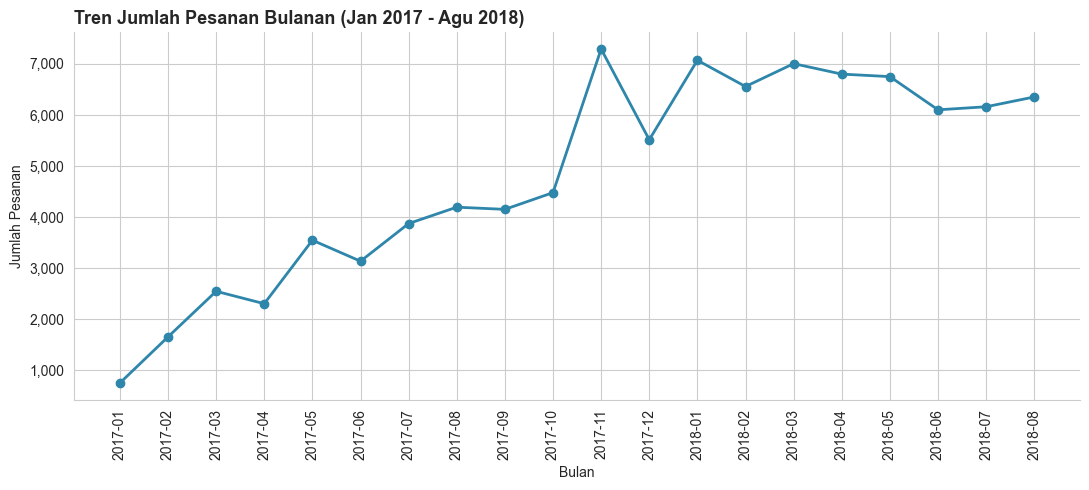

In [25]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    monthly_summary["order_month"],
    monthly_summary["total_orders"],
    marker="o",
    color="#2E86AB",
    linewidth=2,
)
ax.set_title("Tren Jumlah Pesanan Bulanan (Jan 2017 - Agu 2018)", loc="left", fontweight="bold", fontsize=13)
ax.set_xlabel("Bulan")
ax.set_ylabel("Jumlah Pesanan")
ax.tick_params(axis="x", rotation=90)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

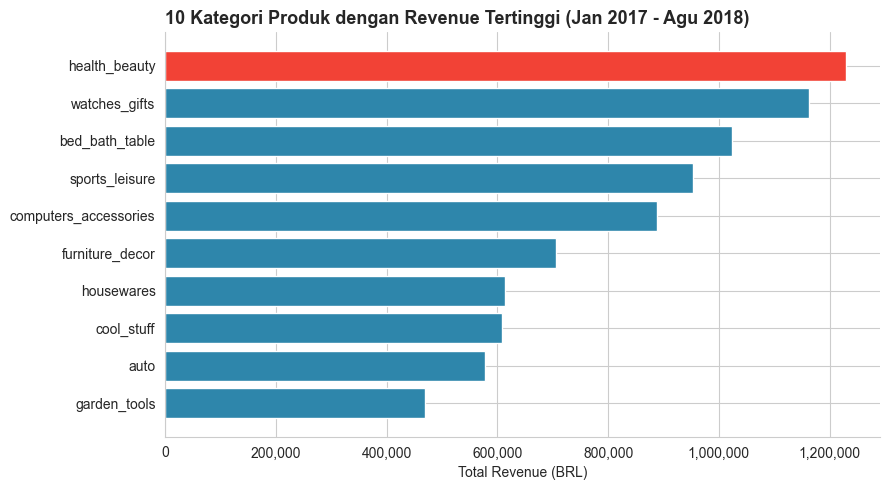

In [26]:
colors = ["#2E86AB" if i > 0 else "#F24236" for i in range(len(category_revenue))]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(category_revenue["product_category_name_english"][::-1], category_revenue["total_revenue"][::-1], color=colors[::-1])
ax.set_title("10 Kategori Produk dengan Revenue Tertinggi (Jan 2017 - Agu 2018)", loc="left", fontweight="bold", fontsize=13)
ax.set_xlabel("Total Revenue (BRL)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana segmentasi pelanggan berdasarkan RFM Analysis, dan segmen mana yang perlu diprioritaskan?

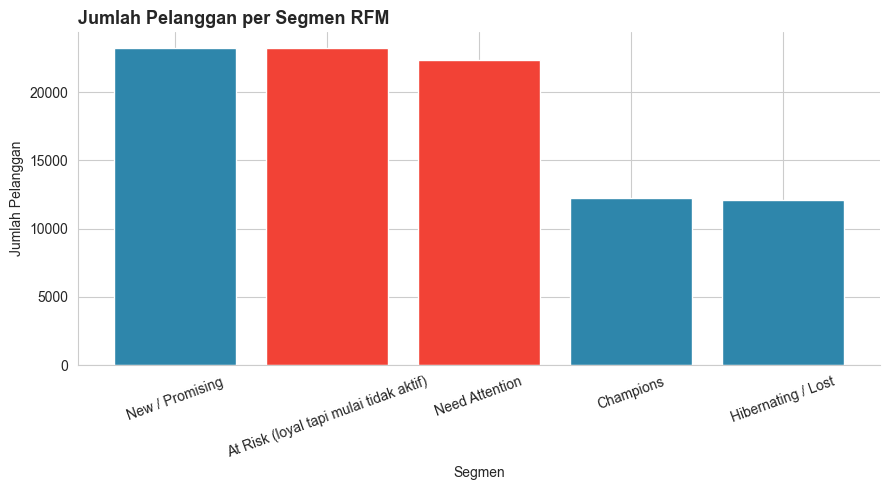

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
order = segment_summary.sort_values("jumlah_pelanggan", ascending=False)
colors = ["#F24236" if s in ["At Risk (loyal tapi mulai tidak aktif)", "Need Attention"] else "#2E86AB" for s in order["segment"]]
ax.bar(order["segment"], order["jumlah_pelanggan"], color=colors)
ax.set_title("Jumlah Pelanggan per Segmen RFM", loc="left", fontweight="bold", fontsize=13)
ax.set_xlabel("Segmen")
ax.set_ylabel("Jumlah Pelanggan")
ax.tick_params(axis="x", rotation=20)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

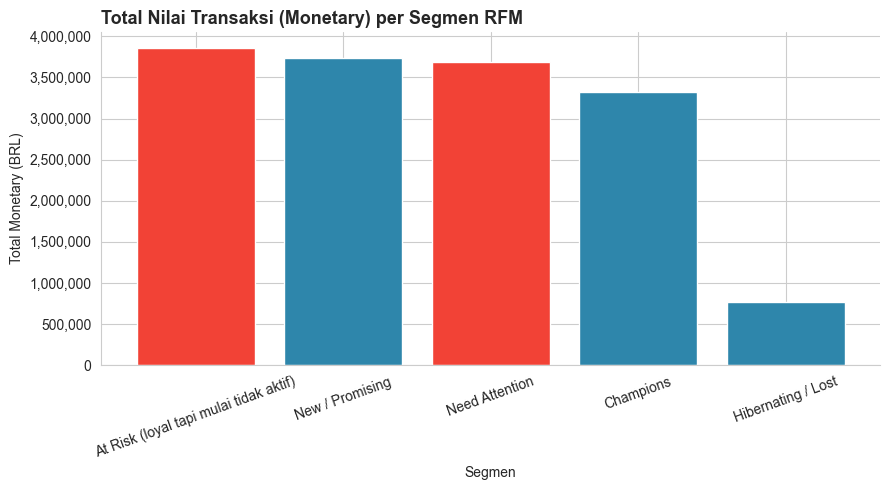

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))
order2 = segment_summary.sort_values("total_monetary", ascending=False)
colors2 = ["#F24236" if s in ["At Risk (loyal tapi mulai tidak aktif)", "Need Attention"] else "#2E86AB" for s in order2["segment"]]
ax.bar(order2["segment"], order2["total_monetary"], color=colors2)
ax.set_title("Total Nilai Transaksi (Monetary) per Segmen RFM", loc="left", fontweight="bold", fontsize=13)
ax.set_xlabel("Segmen")
ax.set_ylabel("Total Monetary (BRL)")
ax.tick_params(axis="x", rotation=20)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Pertanyaan 3: Negara bagian mana yang memiliki rata-rata waktu pengiriman terlama, dan bagaimana hubungannya dengan skor ulasan?

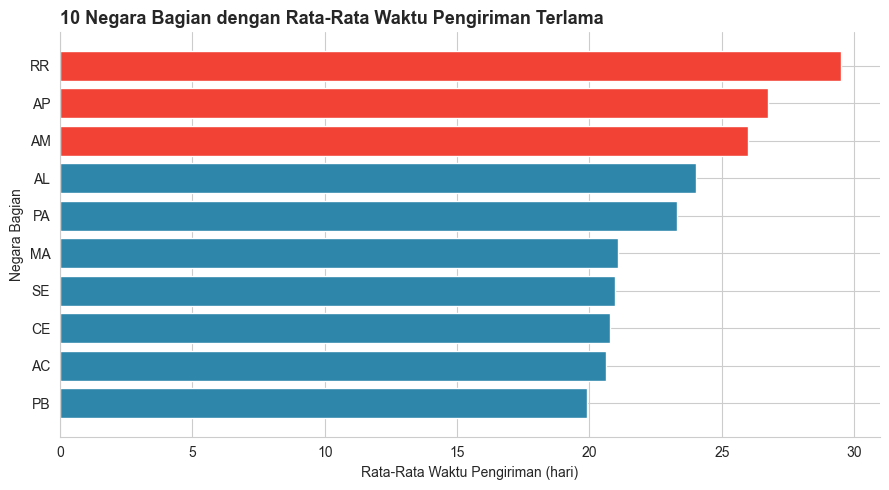

In [29]:
top_states = state_summary.sort_values("avg_delivery_days", ascending=False).head(10)
colors3 = ["#F24236" if i < 3 else "#2E86AB" for i in range(len(top_states))]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_states["customer_state"][::-1], top_states["avg_delivery_days"][::-1], color=colors3[::-1])
ax.set_title("10 Negara Bagian dengan Rata-Rata Waktu Pengiriman Terlama", loc="left", fontweight="bold", fontsize=13)
ax.set_xlabel("Rata-Rata Waktu Pengiriman (hari)")
ax.set_ylabel("Negara Bagian")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

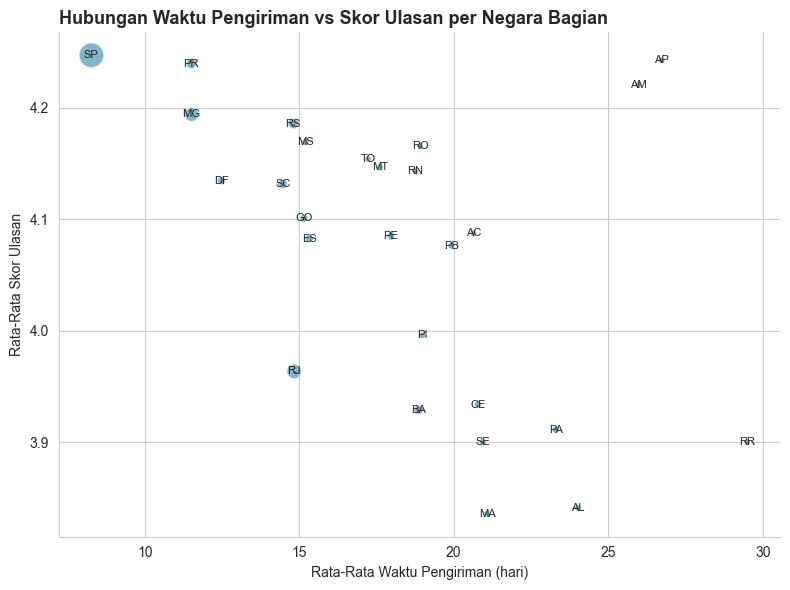

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))
sizes = state_summary["jumlah_pesanan"] / state_summary["jumlah_pesanan"].max() * 300 + 20
scatter = ax.scatter(
    state_summary["avg_delivery_days"],
    state_summary["avg_review_score"],
    s=sizes,
    alpha=0.6,
    color="#2E86AB",
    edgecolor="white",
)
for _, row in state_summary.iterrows():
    ax.annotate(row["customer_state"], (row["avg_delivery_days"], row["avg_review_score"]), fontsize=8, ha="center", va="center")
ax.set_title("Hubungan Waktu Pengiriman vs Skor Ulasan per Negara Bagian", loc="left", fontweight="bold", fontsize=13)
ax.set_xlabel("Rata-Rata Waktu Pengiriman (hari)")
ax.set_ylabel("Rata-Rata Skor Ulasan")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Insight:**
- Grafik tren menunjukkan pertumbuhan jumlah pesanan yang kuat selama 2017 dengan puncak pada November 2017, kemudian bergerak stabil di sepanjang 2018; kategori `health_beauty`, `watches_gifts`, dan `bed_bath_table` konsisten menjadi kontributor revenue terbesar sehingga layak menjadi fokus promosi/stok utama.
- Segmen `At Risk` dan `Need Attention` memiliki jumlah pelanggan dan total nilai transaksi historis terbesar namun berisiko churn, sehingga rekomendasi retensi paling relevan diarahkan pada kedua segmen ini.
- Negara bagian dengan waktu pengiriman terlama (RR, AP, AM, AL, PA) juga cenderung memiliki skor ulasan yang lebih rendah, menunjukkan bahwa perbaikan logistik di wilayah tersebut berpotensi meningkatkan kepuasan pelanggan.

## Analisis Lanjutan (Opsional)

Sebagai pelengkap RFM Analysis pada Pertanyaan 2, dilakukan clustering manual (binning) terhadap nilai transaksi (monetary) pelanggan menjadi kelompok Low, Medium, dan High value tanpa menggunakan algoritma machine learning, untuk mempermudah interpretasi bisnis.

In [31]:
bins = [0, 100, 300, rfm["monetary"].max() + 1]
labels = ["Low Value (<=100 BRL)", "Medium Value (100-300 BRL)", "High Value (>300 BRL)"]
rfm["value_group"] = pd.cut(rfm["monetary"], bins=bins, labels=labels)

value_group_summary = rfm.groupby("value_group", observed=True).agg(
    jumlah_pelanggan=("customer_unique_id", "count"),
    total_monetary=("monetary", "sum"),
).reset_index()
value_group_summary["persentase_pelanggan"] = (
    value_group_summary["jumlah_pelanggan"] / value_group_summary["jumlah_pelanggan"].sum() * 100
).round(2)
value_group_summary

,value_group,jumlah_pelanggan,total_monetary,persentase_pelanggan
0,Low Value (<=100 BRL),43136,2603687.28,46.33
1,Medium Value (100-300 BRL),39671,6585406.91,42.61
2,High Value (>300 BRL),10297,6186781.25,11.06


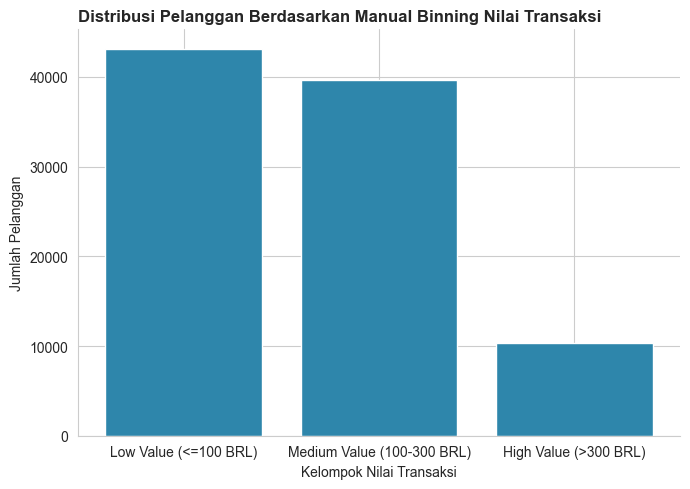

In [32]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(value_group_summary["value_group"], value_group_summary["jumlah_pelanggan"], color="#2E86AB")
ax.set_title("Distribusi Pelanggan Berdasarkan Manual Binning Nilai Transaksi", loc="left", fontweight="bold", fontsize=12)
ax.set_xlabel("Kelompok Nilai Transaksi")
ax.set_ylabel("Jumlah Pelanggan")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Insight:**
- Sebagian besar pelanggan berada pada kelompok Low-Medium Value, sementara kelompok High Value berjumlah lebih kecil namun berkontribusi tidak proporsional besar terhadap total revenue, sehingga program loyalitas khusus untuk kelompok High Value dapat memberikan dampak signifikan terhadap retensi revenue.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Jumlah pesanan tumbuh pesat sepanjang 2017 dan mencapai puncaknya pada November 2017, lalu stabil di kisaran 6.000-7.300 pesanan per bulan sepanjang 2018. Kategori `health_beauty`, `watches_gifts`, dan `bed_bath_table` merupakan tiga kontributor revenue terbesar selama Januari 2017 - Agustus 2018.
- **Conclusion pertanyaan 2:** Segmentasi RFM menunjukkan bahwa segmen `At Risk` dan `Need Attention` menyumbang porsi terbesar dari total nilai transaksi historis namun berisiko churn karena sudah lama tidak bertransaksi, sementara segmen `Champions` adalah pelanggan bernilai tinggi yang baru saja aktif bertransaksi.
- **Conclusion pertanyaan 3:** Negara bagian di wilayah Utara/Timur Laut Brazil (RR, AP, AM, AL, PA) memiliki rata-rata waktu pengiriman terlama, dan wilayah dengan waktu pengiriman lebih lama secara konsisten memiliki rata-rata skor ulasan yang lebih rendah (korelasi negatif).

**Rekomendasi Action Item:**
- Menjalankan kampanye retensi (voucher/diskon personal atau push notification reaktivasi) yang ditargetkan khusus pada pelanggan di segmen `At Risk` dan `Need Attention`, karena kedua segmen ini memiliki potensi nilai transaksi besar namun berisiko churn.
- Memprioritaskan ketersediaan stok dan promosi pada kategori `health_beauty`, `watches_gifts`, dan `bed_bath_table` yang terbukti menjadi penyumbang revenue terbesar.
- Melakukan evaluasi mitra logistik/opsi pengiriman tambahan khusus untuk negara bagian dengan waktu pengiriman terlama (RR, AP, AM, AL, PA) agar waktu pengiriman lebih dekat dengan estimasi, sehingga skor ulasan pelanggan di wilayah tersebut dapat meningkat.